Found 5 files:
  - distance_log_a.txt
  - distance_log_a+se3+atan.txt
  - distance_log_.txt
  - distance_log_se3.txt
  - distance_log_a+se3.txt
a: 7275 data points, 1000 points after sampling, window=50
a+se3+atan: 3537 data points, 1000 points after sampling, window=50
baseline: 7682 data points, 1000 points after sampling, window=50
se3: 5809 data points, 1000 points after sampling, window=50
a+se3: 6484 data points, 1000 points after sampling, window=50
Figure saved as 'distance_comparison.png'


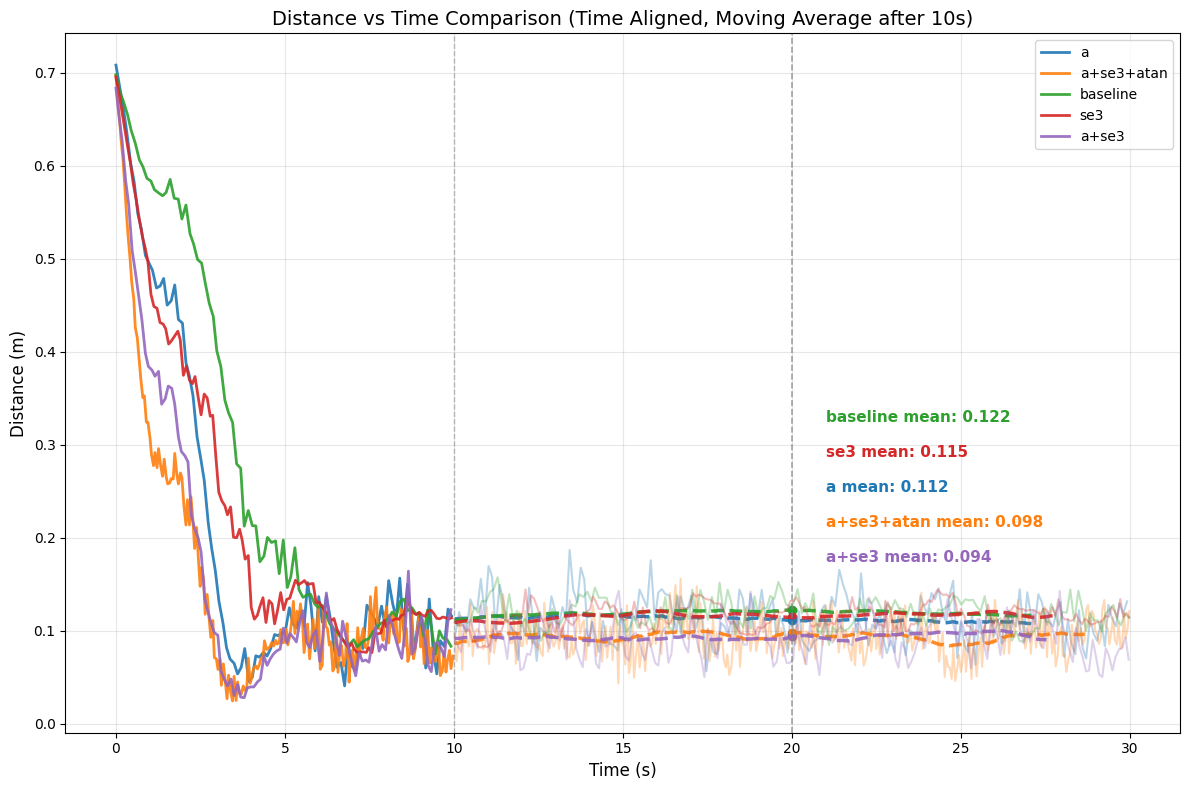

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Moving average function
def moving_average(data, window_size):
    """Calculate moving average"""
    if len(data) < window_size:
        return data
    # Use convolution to implement moving average
    kernel = np.ones(window_size) / window_size
    smoothed = np.convolve(data, kernel, mode='same')
    return smoothed

# Get all distance_log files, exclude files containing 'landing'
data_dir = '/home/pc/Fast-Drone-250'
files = glob.glob(os.path.join(data_dir, 'distance_log*.txt'))
files = [f for f in files if 'landing' not in os.path.basename(f)]

print(f"Found {len(files)} files:")
for f in files:
    print(f"  - {os.path.basename(f)}")

# Read data and plot
plt.figure(figsize=(12, 8))

# Moving average window size (adjustable)
window_size = 50

# Use standard matplotlib colors to avoid format issues
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
color_idx = 0

# Store mean values at 20s (or closest to 20s) for annotation
value_at_20_list = []

for file_path in files:
    # Extract curve name from filename (remove distance_log_ prefix and .txt suffix)
    filename = os.path.basename(file_path)
    curve_name = filename.replace('distance_log_', '').replace('.txt', '')
    if curve_name == '':
        curve_name = 'baseline'
    
    # Read data (only two columns: time and distance)
    try:
        data = np.loadtxt(file_path, delimiter=',', usecols=(0, 1))
        
        # Ensure data is 2D array
        if data.ndim == 1:
            data = data.reshape(-1, 2)
        
        # Align time axis: set start time to 0
        time = data[:, 0]
        distance = data[:, 1]
        time_start = time[0]
        time_aligned = time - time_start
        
        # Sample 1000 points uniformly, but limit to 30 seconds
        n_points = min(1000, len(data))
        indices = np.linspace(0, len(data) - 1, n_points, dtype=int)
        time_sampled = time_aligned[indices]
        distance_sampled = distance[indices]
        
        # Limit data to 30 seconds
        mask_30s = time_sampled <= 30.0
        time_sampled = time_sampled[mask_30s]
        distance_sampled = distance_sampled[mask_30s]
        
        # Apply moving average to each curve
        distance_smoothed = moving_average(distance_sampled, window_size)
        
        # Find split point at 10 seconds
        split_time = 10.0
        mask_before = time_sampled < split_time
        mask_after = time_sampled >= split_time
        
        # Separate data before and after 10 seconds
        time_before = time_sampled[mask_before]
        distance_before = distance_sampled[mask_before]
        time_after = time_sampled[mask_after]
        distance_after_raw = distance_sampled[mask_after]
        distance_after_smooth = distance_smoothed[mask_after]
        
        # Limit valid range of moving average (avoid parts where window exceeds data range)
        # Due to mode='same', there will be boundary effects at both ends, only use middle valid part
        valid_start = window_size // 2
        valid_end = len(time_sampled) - window_size // 2
        
        # Find data after 10s and within valid range
        mask_after_valid = mask_after.copy()
        mask_after_valid[:valid_start] = False
        mask_after_valid[valid_end:] = False
        
        time_after_valid = time_sampled[mask_after_valid]
        distance_after_smooth_valid = distance_smoothed[mask_after_valid]
        
        # Get current color (for consistency)
        color = colors[color_idx % len(colors)]
        color_idx += 1
        
        # Plot original data before 10s (solid line)
        if len(time_before) > 0:
            plt.plot(time_before, distance_before, color=color, linewidth=2.0, alpha=0.9, label=curve_name)
        
        # Plot original data after 10s (solid line, faded)
        if len(time_after) > 0:
            plt.plot(time_after, distance_after_raw, color=color, linewidth=1.5, alpha=0.3)
        
        # Plot moving average after 10s (dashed line, only in valid range), no label in legend
        if len(time_after_valid) > 0:
            plt.plot(time_after_valid, distance_after_smooth_valid, color=color, linewidth=2.5, alpha=0.9, linestyle='--')
            
            # Record mean point near 20s (if 20s not in range, use closest value)
            idx_20 = np.argmin(np.abs(time_after_valid - 20.0))
            time_20 = time_after_valid[idx_20]
            value_20 = distance_after_smooth_valid[idx_20]
            value_at_20_list.append((curve_name, color, time_20, value_20))
        
        print(f"{curve_name}: {len(data)} data points, {n_points} points after sampling, window={window_size}")
        
    except Exception as e:
        print(f"Error reading file {filename}: {e}")

# Draw vertical line at 10s
plt.axvline(x=10.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
# Draw vertical line at 20s and mark mean values for each curve
plt.axvline(x=20.0, color='gray', linestyle='--', alpha=0.7, linewidth=1.2)
# Sort by value at 20s from large to small
value_at_20_list_sorted = sorted(value_at_20_list, key=lambda x: x[3], reverse=True)
for idx, (name, color, t20, v20) in enumerate(value_at_20_list_sorted):
    plt.scatter(20.0, v20, color=color, marker='o', s=36)
    # Place text in blank area: offset horizontally to the right, and vertically based on index
    text_x = 20.0 + 1.0  # Offset 2 seconds to the right
    # Get y-axis limits to find blank area
    ylim = plt.ylim()
    y_range = ylim[1] - ylim[0]
    # Place text lower in the plot, spaced vertically (more compact)
    text_y = ylim[1] - (idx + 1) * (y_range * 0.05) - y_range * 0.5  # Move down
    plt.text(text_x, text_y, f"{name} mean: {v20:.3f}", color=color, fontsize=11, va='center', weight='bold')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Distance (m)', fontsize=12)
plt.title('Distance vs Time Comparison (Time Aligned, Moving Average after 10s)', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save the figure
plt.savefig('distance_comparison.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'distance_comparison.png'")
plt.show()


Found 2 landing files:
  - distance_log_landing.txt
  - distance_log_a+se3+landing.txt
baseline_landing: 240 data points, 240 points after sampling
a+se3+landing_: 292 data points, 292 points after sampling
Figure saved as 'landing_height_distance.png'


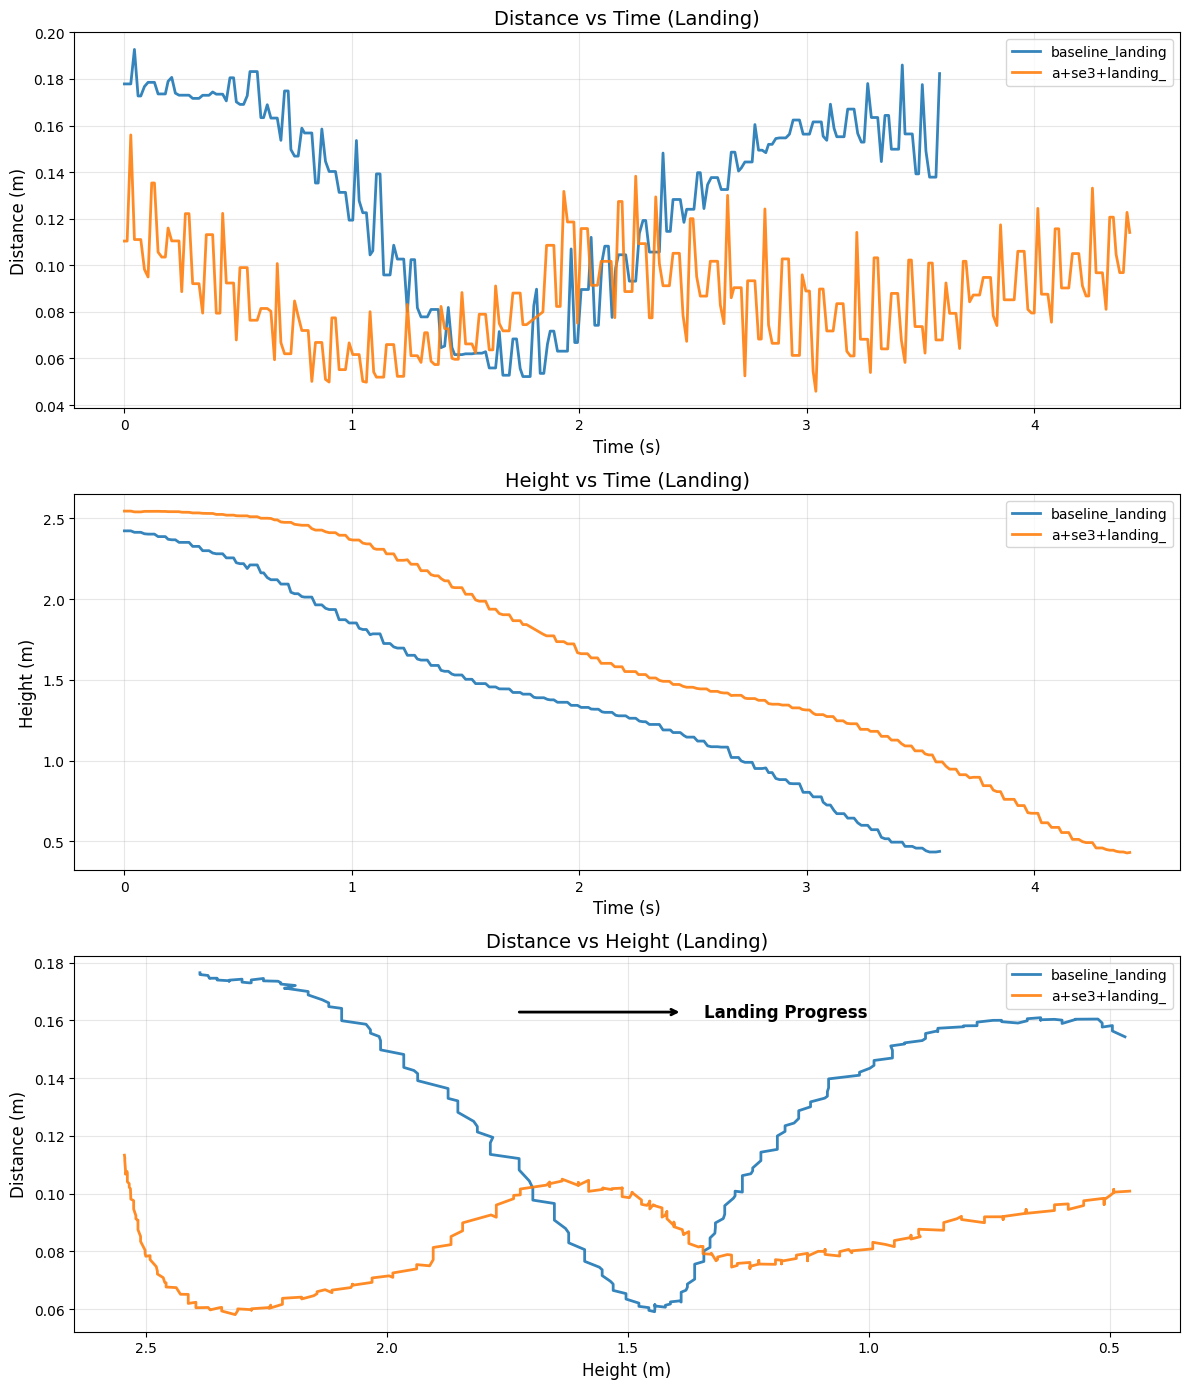

In [31]:
# Plot height and distance for landing files
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Moving average function
def moving_average(data, window_size):
    """Calculate moving average"""
    if len(data) < window_size:
        return data
    kernel = np.ones(window_size) / window_size
    smoothed = np.convolve(data, kernel, mode='same')
    return smoothed

# Get landing files
data_dir = '/home/pc/Fast-Drone-250'
landing_files = glob.glob(os.path.join(data_dir, 'distance_log*landing*.txt'))

print(f"Found {len(landing_files)} landing files:")
for f in landing_files:
    print(f"  - {os.path.basename(f)}")

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14))

# Use standard matplotlib colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
color_idx = 0

# Moving average window size
window_size = 20

for file_path in landing_files:
    # Extract curve name from filename
    filename = os.path.basename(file_path)
    curve_name = filename.replace('distance_log_', '').replace('.txt', '').replace('landing', 'landing_')
    if curve_name.startswith('_'):
        curve_name = curve_name[1:]
    if curve_name == 'landing_':
        curve_name = 'baseline_landing'
    
    # Read data (three columns: time, distance, height)
    try:
        data = np.loadtxt(file_path, delimiter=',', usecols=(0, 1, 2))
        
        # Ensure data is 2D array
        if data.ndim == 1:
            data = data.reshape(-1, 3)
        
        # Align time axis: set start time to 0
        time = data[:, 0]
        distance = data[:, 1]
        height = data[:, 2]
        time_start = time[0]
        time_aligned = time - time_start
        
        # Sample 1000 points uniformly
        n_points = min(1000, len(data))
        indices = np.linspace(0, len(data) - 1, n_points, dtype=int)
        time_sampled = time_aligned[indices]
        distance_sampled = distance[indices]
        height_sampled = height[indices]
        
        # Apply moving average to distance
        distance_smoothed = moving_average(distance_sampled, window_size)
        
        # Limit valid range of moving average (avoid parts where window exceeds data range)
        valid_start = window_size // 2
        valid_end = len(distance_sampled) - window_size // 2
        
        # Get valid range data
        time_valid = time_sampled[valid_start:valid_end]
        distance_valid = distance_sampled[valid_start:valid_end]
        distance_smoothed_valid = distance_smoothed[valid_start:valid_end]
        height_valid = height_sampled[valid_start:valid_end]
        
        # Get current color
        color = colors[color_idx % len(colors)]
        color_idx += 1
        
        # Plot distance on first subplot
        ax1.plot(time_sampled, distance_sampled, color=color, linewidth=2.0, alpha=0.9, label=curve_name)
        
        # Plot height on second subplot
        ax2.plot(time_sampled, height_sampled, color=color, linewidth=2.0, alpha=0.9, label=curve_name)
        
        # Plot height vs distance (smoothed, only valid range) on third subplot
        ax3.plot(height_valid, distance_smoothed_valid, color=color, linewidth=2.0, alpha=0.9, label=curve_name)
        
        print(f"{curve_name}: {len(data)} data points, {n_points} points after sampling")
        
    except Exception as e:
        print(f"Error reading file {filename}: {e}")

# Configure subplots
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Distance (m)', fontsize=12)
ax1.set_title('Distance vs Time (Landing)', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Height (m)', fontsize=12)
ax2.set_title('Height vs Time (Landing)', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

ax3.set_xlabel('Height (m)', fontsize=12)
ax3.set_ylabel('Distance (m)', fontsize=12)
ax3.set_title('Distance vs Height (Landing)', fontsize=14)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.invert_xaxis()  # Reverse x-axis so larger height values are on the left

# Add arrow indicating landing progress (pointing right, since height decreases to the right)
xlim = ax3.get_xlim()
ylim = ax3.get_ylim()
# Place arrow in blank area (upper right)
arrow_x_start = xlim[0] + (xlim[1] - xlim[0]) * 0.4
arrow_x_end = xlim[0] + (xlim[1] - xlim[0]) * 0.55
arrow_y = ylim[1] - (ylim[1] - ylim[0]) * 0.15
ax3.annotate('', xy=(arrow_x_end, arrow_y), xytext=(arrow_x_start, arrow_y),
             arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax3.text(arrow_x_end + (xlim[1] - xlim[0]) * 0.02, arrow_y, 'Landing Progress', 
         fontsize=12, va='center', weight='bold')

plt.tight_layout()
# Save the figure
plt.savefig('landing_height_distance.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'landing_height_distance.png'")
plt.show()
